<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 10 - Sequential Perception and Review</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

## Objective
In this TD, you will implement two models for a new type of task, and you will review everything we have seen so far:
- Sequential perception task
- Implement two models
- Simulate behavior
- Parameter recovery
- Model recovery
- Fit model to data
- Model selection
    - Fixed effect
    - Random effect

In [1]:
from typing import Tuple, Optional

import numpy as np
import pandas as pd
import scipy
from tqdm import trange, tqdm

import seaborn as sns
import matplotlib.pyplot as plt

from models import Model, Parameter
from sequential_perception_task import SequentialPerceptionTask, dist_orange, dist_blue

In [2]:
%reload_ext autoreload
%autoreload 2

## The Task
<img src="images/task_stimuli_distributions.png" alt="Task" style="width: 500px;"/>

Use the `dist_orange` and `dist_blue` distributions to plot the distributions of the two stimuli.
They are implemented as a `scipy.stats` distributions. Two useful methods for these distributions are:
- `pdf(x)`: Probability density function, useful to find how likely a color value is given the distribution.
- `rvs(size)`: Random variates, useful to sample a color values from the distribution.

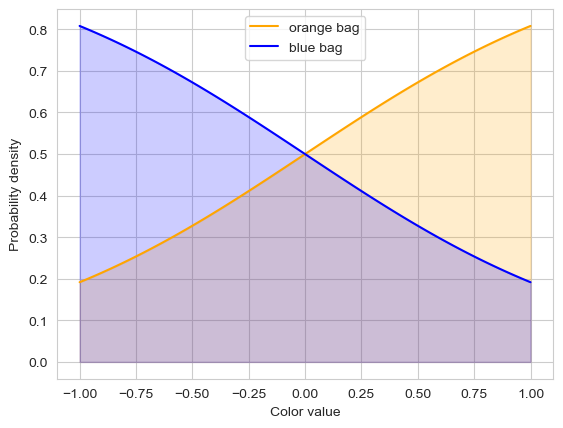

In [3]:
x = np.linspace(-1, 1, 100)
p_orange = dist_orange.pdf(x)
p_blue = dist_blue.pdf(x)

plt.plot(x, p_orange, color='orange', label='orange bag')
plt.plot(x, p_blue, color='blue', label='blue bag')
plt.fill_between(x, p_orange, color='orange', alpha=0.2)
plt.fill_between(x, p_blue, color='blue', alpha=0.2)
plt.xlabel('Color value')
plt.ylabel('Probability density')
plt.legend()
plt.show()

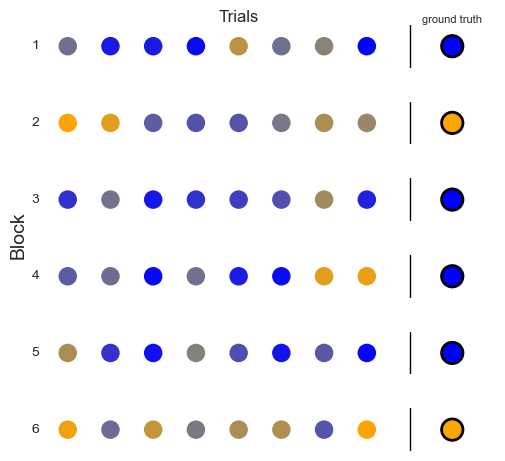

In [4]:
demo_task = SequentialPerceptionTask(n_trials=8, n_blocks=6, seed=42)
demo_task.plot()

## The Models

### Model 1: Integration model
We will create a model that integrates the evidence over time.

In [9]:
class IntegrationModel(Model):
    parameters = [
        Parameter(
            name='leak',
            initial_value=0.1,
            distribution=scipy.stats.uniform(0, 1),
            bounds=(0, 1),
            plausible_bounds=(0.05, 0.8)
        ),
        Parameter(
            name='temperature',
            initial_value=0.1,
            distribution=scipy.stats.expon(scale=0.1),
            bounds=(1e-6, 1),
            plausible_bounds=(0.01, 0.5)
        )
    ]

    def __init__(self, leak: float, temperature: float):
        self.leak: float = leak
        self.temperature: float = temperature
        self.n_blocks: Optional[int] = None
        self.evidence: Optional[np.ndarray[float]] = None

    def update(self, stimulus):
        # Update the evidence with the leak
        p_orange = dist_orange.pdf(stimulus)
        p_blue = dist_blue.pdf(stimulus)
        log_odds_ratio = np.log(p_orange) - np.log(p_blue) # Todo: on appelle bien ca l'evidence?
        self.evidence = self.evidence * (1 - self.leak) + log_odds_ratio

    def policy(self):
        # Softmax policy to compute probability of playing action 1
        np.seterr(over='ignore')
        prob_choose_orange = 1 / (1 + np.exp(-self.evidence / self.temperature))
        np.seterr(over='warn')
        return prob_choose_orange

    def reset(self, n_blocks: int):
        self.n_blocks = n_blocks
        self.evidence = np.zeros((n_blocks, 1))

    def __repr__(self):
        return f"IntegrationModel(lk={self.leak: .2f}, t={self.temperature: .2f})"

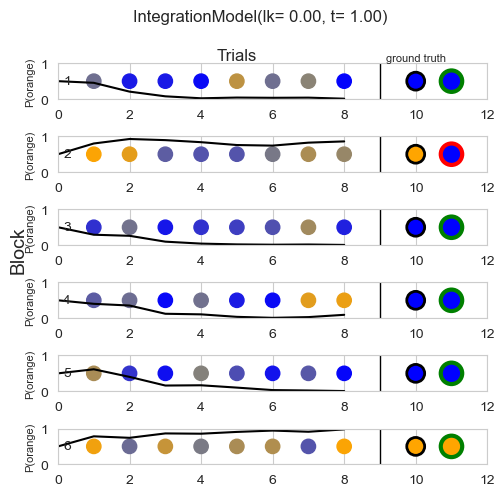

In [10]:
integration_model = IntegrationModel(0, 1)
_ = integration_model.simulate(demo_task, plot=True)

### Model 2: Extremum detection model

In [11]:
class ExtremumDetectionModel(Model):
    parameters = [
        Parameter(
            name='epsilon',
            initial_value=0.1,
            distribution=scipy.stats.uniform(0, 1),
            bounds=(0, 1),
            plausible_bounds=(0.1, 0.4)
        )
    ]
    def __init__(self, epsilon: float):
        self.epsilon: float = epsilon
        self.n_blocks: Optional[int] = None
        self.evidence: Optional[np.ndarray[float]] = None

    def update(self, stimulus):
        update_condition = np.absolute(stimulus) > np.absolute(self.evidence)
        self.evidence = np.where(update_condition, stimulus, self.evidence)

    def policy(self):
        greedy_decision = (self.evidence > 0).astype(int)
        p_orange = greedy_decision * (1 - self.epsilon) + (1 - greedy_decision) * self.epsilon
        return p_orange.astype(float)

    def reset(self, n_blocks: int):
        self.n_blocks = n_blocks
        self.evidence = np.zeros((n_blocks, 1))

    def __repr__(self):
        return f'ExtremumDetectionModel(epsilon={self.epsilon: .2f})'

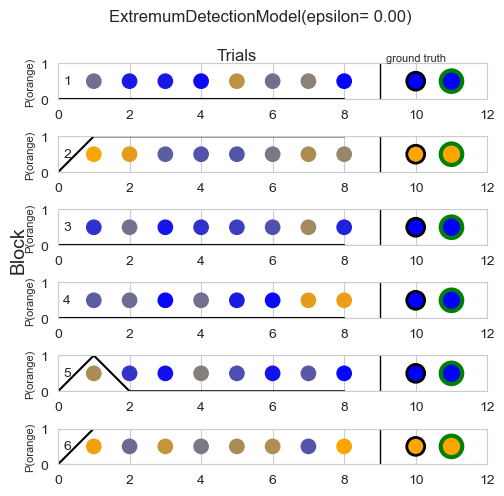

In [12]:
extremum_model = ExtremumDetectionModel(0)
_ = extremum_model.simulate(demo_task, plot=True)

### Akaike Informaction Criterion

$$
\text{AIC} = -2 \cdot \log L + 2k
$$
Where:
- $L$ is the likelihood of the behavior given the fitted model
- $k$ is the number of parameters in the model

In [ ]:
def akaike_information_criterion(model, task, choices) -> float:
    k = len(model.parameters)
    ll = ...
    aic = ...
    return aic

In [13]:
def akaike_information_criterion(model, task, choices) -> float:
    k = len(model.parameters)
    ll = model.log_likelihood(task, choices)
    aic = -2 * ll + 2 * k
    return aic

## Parameter recovery
### Write the functions
> Note: To debug your functions, you can run it on Model 1 with n_samplings=2.

Complete the `perform_parameter_recovery` function to perform parameter recovery for a model given model.

In [14]:
def perform_parameter_recovery(task, ModelClass, n_samplings):
    results = []
    for i in trange(n_samplings):
        # Sample parameters and instantiate original model
        ## CAREFUL! This part has changed :)
        original_params = {
            parameter.name: parameter.distribution.rvs()
            for parameter in ModelClass.parameters
        }
        original_model = ModelClass(**original_params)

        # Simulate task with the original model
        choices = original_model.simulate(task)

        # Fit the model to the simulated data
        recovered_model = ModelClass.fit(task, choices, verbose=False)

        recovered_params = {
            f"recovered_{parameter.name}": getattr(recovered_model, parameter.name)
            for parameter in ModelClass.parameters
        }

        results.append(pd.Series({**original_params, **recovered_params}))
    return pd.concat(results, axis=1).transpose()

In [15]:
def plot_param_recovery_confusion_matrix(param_recovery_results: pd.DataFrame):
    correlations = param_recovery_results.corr()
    row_names = [col_name for col_name in param_recovery_results.columns if 'recovered' in col_name]
    column_names = [col_name for col_name in param_recovery_results.columns if 'recovered' not in col_name]
    confusion_matrix = correlations.loc[row_names, column_names]

    plt.figure(figsize=(3, 2))
    sns.heatmap(confusion_matrix, center=0, annot=True, fmt='.2f', cmap='coolwarm')
    plt.show()


## Define the task to study

In [16]:
task = SequentialPerceptionTask(n_trials=8, n_blocks=200, seed=42)

### Parameter recovery for Model 1


In [17]:
param_recov_result_1 = perform_parameter_recovery(task, IntegrationModel, 30)

100%|██████████| 30/30 [00:12<00:00,  2.31it/s]


In [18]:
param_recov_result_1

,leak,temperature,recovered_leak,recovered_temperature
0,0.965822,0.056651,1.000000,0.036305
1,0.511307,0.190765,0.536130,0.126272
2,0.212224,0.062982,0.224389,0.057860
3,0.204632,0.064200,0.211559,0.000044
4,0.795580,0.025568,0.794719,0.015395
5,0.047378,0.157105,0.070155,0.089596
6,0.200405,0.057280,0.163503,0.000106
7,0.670594,0.028728,0.672993,0.000249
8,0.625835,0.076269,0.674378,0.072223
9,0.694169,0.045453,0.686092,0.080309


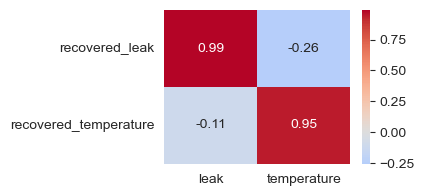

In [19]:
plot_param_recovery_confusion_matrix(param_recov_result_1)

### Parameter recovery for Model 2

In [20]:
param_recov_result_2 = perform_parameter_recovery(task, ExtremumDetectionModel, 30)
param_recov_result_2

  0%|          | 0/30 [00:00<?, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
100%|██████████| 30/30 [00:04<00:00,  6.33it/s]


,epsilon,recovered_epsilon
0,0.833561,0.824944
1,0.174615,0.229177
2,0.809549,0.773828
3,0.467322,0.459949
4,0.106926,0.115001
5,0.871656,0.836084
6,0.149781,0.159965
7,0.143374,0.124953
8,0.155223,0.159763
9,0.861858,0.859412


<Axes: xlabel='epsilon', ylabel='recovered_epsilon'>

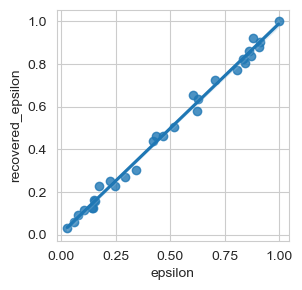

In [21]:
plt.figure(figsize=(3, 3))
sns.regplot(param_recov_result_2, x='epsilon', y='recovered_epsilon')

## Model Recovery


In [22]:
def perform_model_recovery(task, model_classes, n_rounds):
    # Instantiate the results as a zero matrix with the model names as row and column labels
    model_names = [model_class.__name__ for model_class in model_classes]
    results = pd.DataFrame(data=0, columns=model_names, index=model_names)
    
    for _ in trange(n_rounds):
        
        for simul_idx, simul_model_class in enumerate(model_classes):
            ########################################################
            ### Simulate the task with the model
            #####
            # Sample parameters for your simulating model using their distributions
            # defined in the .parameters attribute of the model class
            simul_parameters = {
                parameter.name: parameter.distribution.rvs()
                for parameter in simul_model_class.parameters
            }
            simulating_model = simul_model_class(**simul_parameters)
            simulated_choices = simulating_model.simulate(task)

            #########################################################
            ### Fit all candidate models to the simulated data
            ####

            # Loop through all candidate models, fit them and get the AIC for each of them
            aics = []
            for candidate_model_class in model_classes:
                fitted_candidate_model = candidate_model_class.fit(task, simulated_choices, verbose=False)
                aic = akaike_information_criterion(fitted_candidate_model, task, simulated_choices)
                aics.append(aic)

            #######################################################
            ### Select the winning model
            ####

            # Retrieve the index of the model with the best AIC
            select_idx = np.argmin(aics)
            results.iloc[simul_idx, select_idx]  += 1

    return results

Run your function on the task and the models.

In [23]:
model_classes = [IntegrationModel, ExtremumDetectionModel]
model_recovery_results = perform_model_recovery(task, model_classes, n_rounds=30)

  0%|          | 0/30 [00:00<?, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
100%|██████████| 30/30 [00:35<00:00,  1.20s/it]


Write a function that plots the inversion matrix of the model recovery results.
> Note: Although in TD 7, we first computed the confusion matrix, it is not a necessary step. You can directly compute the inversion matrix by performing the appropriate normalization on the model recovery results.

In [24]:
def plot_model_recovery_inversion_matrix(model_recovery_results: pd.DataFrame):
    # Compute the inversion matrix (com
    inversion_matrix = model_recovery_results.div(model_recovery_results.sum(axis=0), axis=1)
    # Make a heatmap with appropriate title and axis labels
    sns.heatmap(inversion_matrix, annot=True, fmt='.2f')
    plt.title(f"P(simulated | winning)")
    plt.xlabel("Winning model", fontsize=12)
    plt.ylabel("Simulated model", fontsize=12)

    plt.show()

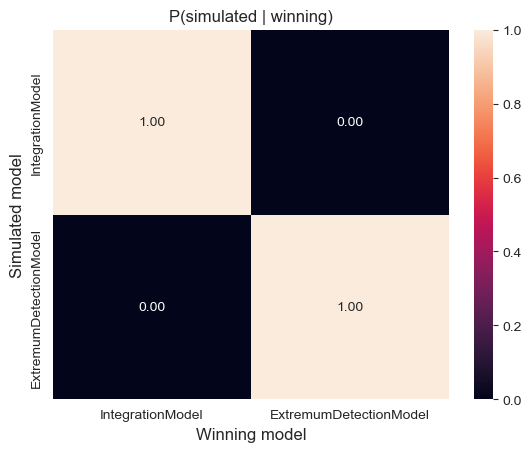

In [25]:
plot_model_recovery_inversion_matrix(model_recovery_results)

## Subject Data

### Load and inspect the data

In [26]:
data = pd.read_csv('data.csv', index_col=0)
data

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
subject,,,,,,,,,,,,,,,,,,,,,
S01,0,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,1,1,1,0,0
S02,0,1,0,1,1,1,0,0,0,1,...,1,0,1,0,0,0,0,1,0,0
S03,0,0,0,1,1,0,0,0,1,1,...,0,0,1,0,1,1,1,1,0,0
S04,0,1,0,0,1,1,0,0,0,0,...,0,0,1,1,0,0,0,1,1,1
S05,0,1,0,0,0,1,0,0,0,1,...,0,0,1,0,0,1,1,1,0,0
S06,0,1,0,0,1,1,0,0,0,1,...,0,0,1,0,0,1,1,1,0,0
S07,0,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
S08,0,1,0,0,1,1,1,1,0,0,...,0,1,0,0,0,1,1,1,0,1


## Fit the models to each subject

In [27]:
model_classes = [IntegrationModel, ExtremumDetectionModel]
model_names = [model_class.__name__ for model_class in model_classes]
n_models = len(model_classes)
n_subjects = len(data)

In [28]:
def fit_all_models_to_each_subject(model_classes, task, data: pd.DataFrame):
    fitted_models = {}
    aics = {}
    for subject_id, subject_choices in tqdm(data.iterrows()):
        subject_choices = subject_choices.values.reshape(-1, 1)
        fitted_models[subject_id] = {}
        aics[subject_id] = {}
        for model_class in model_classes:
            model_name = model_class.__name__
            # Fit the model to the subject's choices
            fitted_model = model_class.fit(task , subject_choices, verbose=False)
            fitted_models[subject_id][model_name] = fitted_model

            # Compute the AIC for the fitted model
            aics[subject_id][model_name] = akaike_information_criterion(fitted_model, task, subject_choices)
    return fitted_models, aics

fitted_models, aics = fit_all_models_to_each_subject(model_classes, task, data)

0it [00:00, ?it/s]/Users/amrictrudel/anaconda3/envs/ccm/lib/python3.11/site-packages/pybads/init_functions/init_sobol.py:39: RuntimeWarning: invalid value encountered in cast
  str_seed = u0[0 : np.minimum(11, len(u0))].astype(np.uint64)
8it [00:04,  1.73it/s]


In [60]:
aics

{'S01': {'IntegrationModel': np.float64(177.87492275639673),
  'ExtremumDetectionModel': np.float64(127.58234429612885)},
 'S02': {'IntegrationModel': np.float64(258.333371976123),
  'ExtremumDetectionModel': np.float64(199.35693551737504)},
 'S03': {'IntegrationModel': np.float64(289.93440240979174),
  'ExtremumDetectionModel': np.float64(255.67145721952548)},
 'S04': {'IntegrationModel': np.float64(291.66324704409203),
  'ExtremumDetectionModel': np.float64(260.97873410878015)},
 'S05': {'IntegrationModel': np.float64(13.804924893073833),
  'ExtremumDetectionModel': np.float64(160.31288895677528)},
 'S06': {'IntegrationModel': np.float64(97.87712537869506),
  'ExtremumDetectionModel': np.float64(174.51397582408777)},
 'S07': {'IntegrationModel': np.float64(20.55986522877802),
  'ExtremumDetectionModel': np.float64(204.90250444870208)},
 'S08': {'IntegrationModel': np.float64(157.59300605497378),
  'ExtremumDetectionModel': np.float64(244.6272397747589)}}

## Model Selection
We will use a new model selection method: **Bayesian Model Selection** (BMS). The calculations are quite involved, so we will not see in detail how it works. The program was [originally written in Matlab](https://github.com/spm/spm/blob/main/spm_BMS.m) and has been ported to Python in the `bayesian_model_selection.py` file.

Produce a matrix of log-likelihoods for each model and each subject.

In [61]:
log_model_evidence_by_subject = pd.DataFrame(aics).T / -2
log_model_evidence_by_subject

,IntegrationModel,ExtremumDetectionModel
S01,-88.937461,-63.791172
S02,-129.166686,-99.678468
S03,-144.967201,-127.835729
S04,-145.831624,-130.489367
S05,-6.902462,-80.156444
S06,-48.938563,-87.256988
S07,-10.279933,-102.451252
S08,-78.796503,-122.313620


### Fixed effect model selection

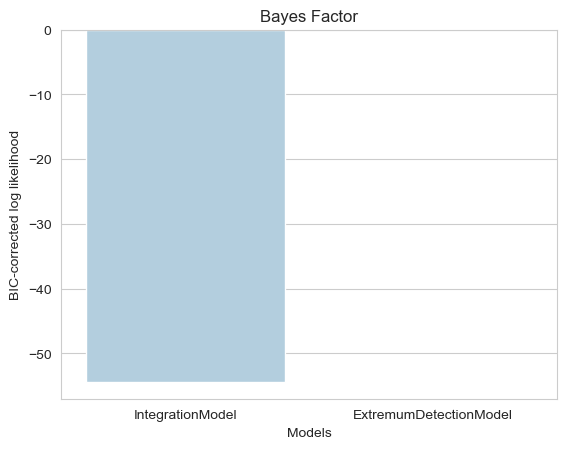

In [42]:
def plot_bayes_factor(log_model_evidence_by_subject):
    summed_log_model_evidence = log_model_evidence_by_subject.sum(axis=0)
    # Todo : Mon Copilot me fait faire  bayes_factor = np.exp(summed_log_model_evidence) -> log bayes factor
    bayes_factor = summed_log_model_evidence - summed_log_model_evidence.max()
    sns.barplot(x=bayes_factor.index, y=bayes_factor.values, hue=bayes_factor.index, palette='Blues')
    plt.title("Bayes Factor")
    plt.xlabel("Models")
    plt.ylabel("BIC-corrected log likelihood")
    plt.show()

plot_bayes_factor(log_model_evidence_by_subject)

### Random effect model selection

Input your matrix to BMS and get the results.

In [43]:
log_model_evidence_by_subject

,IntegrationModel,ExtremumDetectionModel
S01,-36.392352,-1.000152
S02,-74.018144,-56.107993
S03,-87.522308,-69.331497
S04,-96.107788,-56.108027
S05,-92.752171,-1.008798
S06,-3.151847,-44.966992
S07,-2.000100,-51.040242
S08,-60.898970,-68.301167
S09,-9.702675,-60.295332


Normalize the `model_probs`